In [18]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import astropy.constants as c
import astropy.units as u
import matplotlib.pyplot as plt
from torch.utils.data import random_split
from BPNN import VectorScalarDataset, ScalarNN, BPNN

def cd_sed(nu, Beta, T, a=1):
    nu_c = 545 #GHz
    h_over_k = (c.h/c.k_B/(1*u.K)).to('GHz-1').value
    return a*(nu/nu_c)**(Beta+1)*(np.exp(h_over_k*nu_c/T) - 1)/(np.exp(h_over_k*nu/T) - 1)

def integral(bp_shift, Beta, T, bp_dat):
    return np.sum(bp_dat[1]*cd_sed(bp_dat[0]+bp_shift, Beta, T))

In [19]:
# Device configuration: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_data = torch.load("dataset_train_MBB_353.pt")
test_data = torch.load("dataset_val_MBB_353.pt")

y_mean = train_data["y"].mean()
y_std  = train_data["y"].std()

y_mean_test = test_data["y"].mean()
y_std_test  = test_data["y"].std()

print("TRAINING DATASET, parameters order:")
print(f"Bandpass shift: mean={train_data['X'][:,0].mean():.2f}, std={train_data['X'][:,0].std():.2f}")
print(f"          Beta: mean={train_data['X'][:,1].mean():.2f}, std={train_data['X'][:,1].std():.2f}")
print(f"             T: mean={train_data['X'][:,2].mean():.2f}, std={train_data['X'][:,2].std():.2f}")
print(f"--------------------------------------")
print(f"       targets: mean={y_mean:.2f}, std={y_std:.2f}")

# Normalize
y_train_norm = (train_data["y"] - y_mean) / y_std
y_test_norm = (test_data["y"] - y_mean) / y_std

dataset_unnorm = VectorScalarDataset(train_data["X"], train_data["y"])
test_dataset = VectorScalarDataset(test_data["X"], test_data["y"])

total = len(dataset_unnorm)
val_size   = int(0.2 * total)
train_size = total - val_size

train_dataset, val_dataset = random_split(dataset_unnorm, [train_size, val_size])
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader  = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


TRAINING DATASET, parameters order:
Bandpass shift: mean=-0.86, std=5.46
          Beta: mean=1.90, std=0.17
             T: mean=12.00, std=1.15
--------------------------------------
       targets: mean=274.40, std=27.56


MODEL:
BPNN(
  (in_l): Linear(in_features=3, out_features=8, bias=True)
  (hl_1): Linear(in_features=8, out_features=8, bias=True)
  (hl_2): Linear(in_features=8, out_features=8, bias=True)
  (hl_3): Linear(in_features=8, out_features=8, bias=True)
  (out_l): Linear(in_features=8, out_features=1, bias=True)
)
Trainable parameters: 257
Total FLOPs: 448
Epoch 1: train=0.2494  val=0.0395
Epoch 2: train=0.0133  val=0.0033
Epoch 3: train=0.0019  val=0.0012
Epoch 4: train=0.0009  val=0.0006
Epoch 5: train=0.0005  val=0.0005
Epoch 6: train=0.0005  val=0.0005
Epoch 7: train=0.0005  val=0.0005
Epoch 8: train=0.0005  val=0.0005
Epoch 9: train=0.0005  val=0.0004
Epoch 10: train=0.0005  val=0.0005
Epoch 11: train=0.0005  val=0.0004
Epoch 12: train=0.0005  val=0.0004
Epoch 13: train=0.0005  val=0.0004
Epoch 14: train=0.0005  val=0.0005
Epoch 15: train=0.0005  val=0.0005
Epoch 16: train=0.0005  val=0.0005
Epoch 17: train=0.0005  val=0.0005
Epoch 18: train=0.0005  val=0.0004
Epoch 19: train=0.0005  v

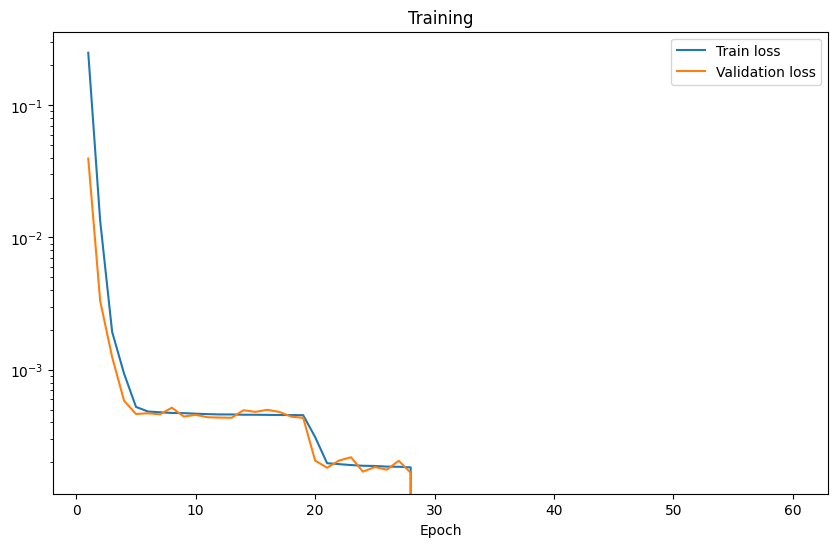

In [ ]:
BPmodel = BPNN(seed=1234)
criterion = nn.HuberLoss()
optimizer = optim.Adam(BPmodel.parameters(), lr=1e-4)
print(BPmodel)
BPmodel.fit(dataset_unnorm, epochs=60)
BPmodel.plot_training(out_path='training.png')

In [21]:
BPmodel.save('bandpass_NN_v2_MBB_353.pth')

BPmodel = BPNN()
BPmodel.load('bandpass_NN_v2_MBB_353.pth')

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

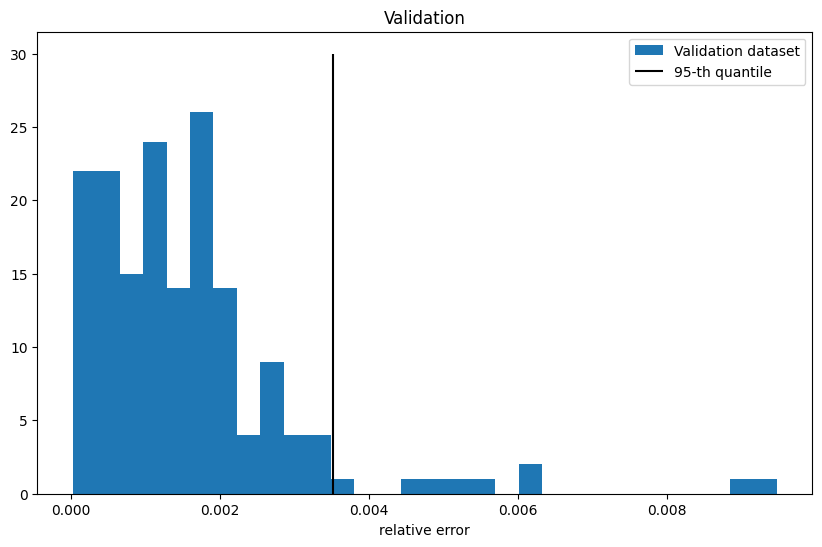

In [22]:
errs = []
# total_val_loss = 0
for X_batch, y_batch in test_loader:
    X_batch = X_batch #.to(device)  # move inputs to GPU
    y_batch = y_batch #.to(device)  # move targets to GPU
    X_b0 = X_batch[0]
    pred_norm = BPmodel.predict(X_b0)
    pred = pred_norm #* y_std + y_mean           # denormalize output
    err = abs((pred - y_batch[0].item()))/y_batch[0].item()
    #print(f"Params: [{X_b0[0]}, {X_b0[1]}, {X_b0[2]}], Preds = {pred.item():.4f}, True = {y_batch[0].item():.4f}, err = {err}")
    errs.append(err)
    # loss  = criterion(pred, y_batch)
    # total_val_loss += loss.item() * len(y_batch)

np.quantile(errs, 0.95)
plt.figure(figsize=(10,6))
plt.title("Validation")
plt.hist(errs, bins=30, label="Validation dataset")
plt.vlines([np.quantile(errs, 0.95)], 0, 30, colors=['black'], label='95-th quantile')
# plt.plot(np.arange(1, num_epochs+1), self.valid_losses, label="Validation loss")
plt.xlabel("relative error")
plt.legend()
plt.savefig('validation_hist.png')
plt.close

/tmp/ipykernel_22190/1820172674.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,
/tmp/ipykernel_22190/1820172674.py:101: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,
/tmp/ipykernel_22190/1820172674.py:151: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,


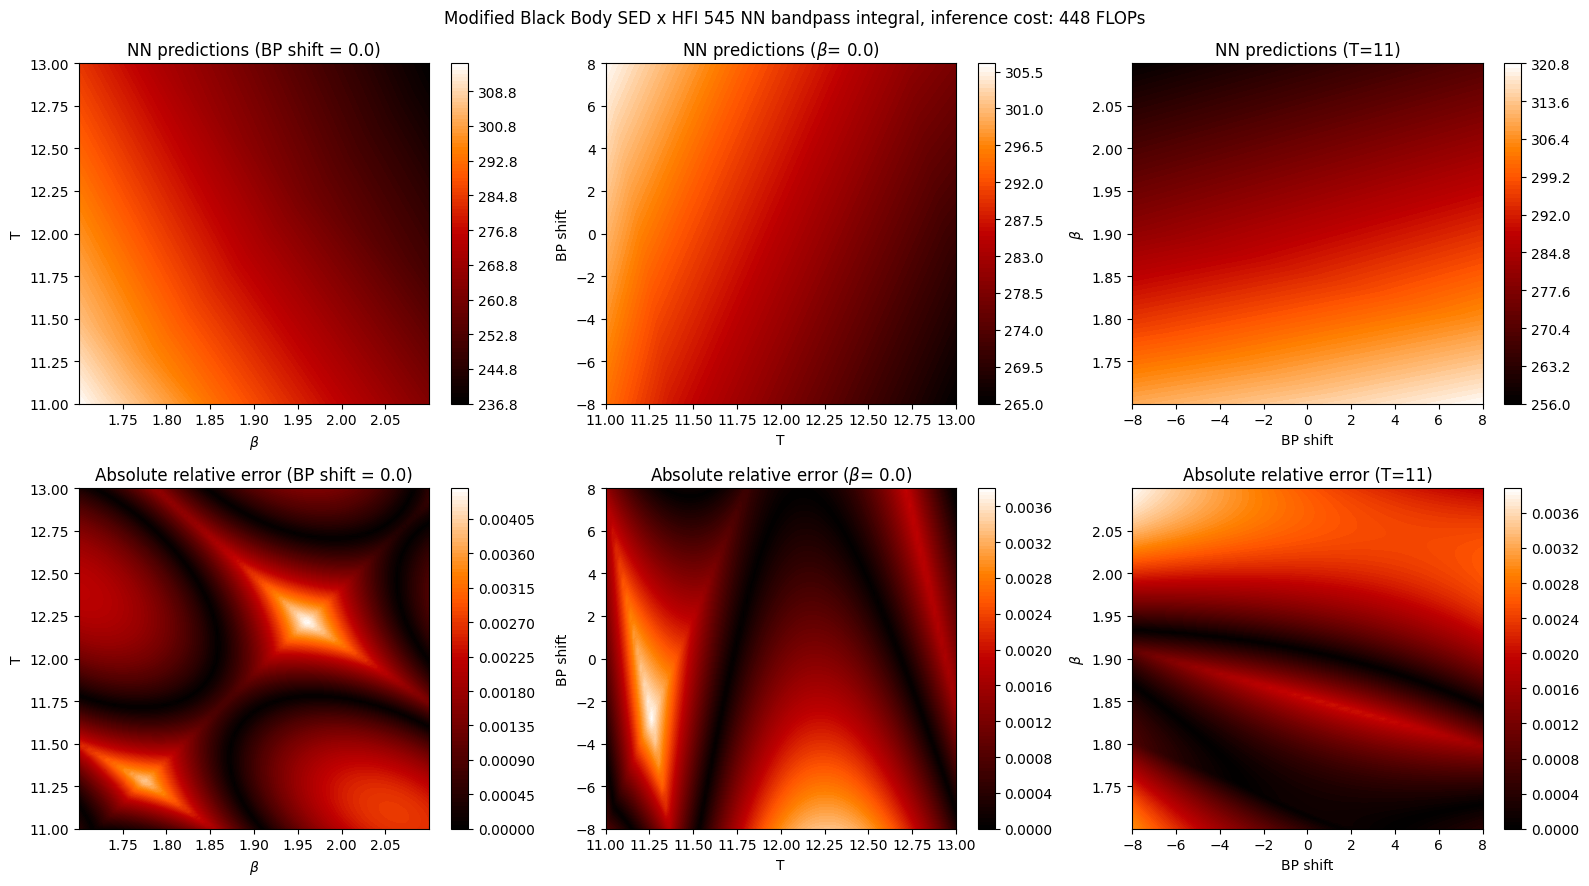

<Figure size 640x480 with 0 Axes>

In [24]:
samp_intervals = {
    "BP_shift":(-8., 8.),
    "Beta":(1.7, 2.1),
    "T":(11., 13.)
}
N_vals = 100
bp_path = "bp_planck_353-1_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

#Torch grid bp fixed
beta_s = torch.linspace(samp_intervals["Beta"][0], samp_intervals["Beta"][1], N_vals)
t_s = torch.linspace(samp_intervals["T"][0], samp_intervals["T"][1], N_vals)
bp_s_fixed = 0.0 

grid_b, grid_t = torch.meshgrid(beta_s, t_s, indexing='ij')
X_grid = torch.stack([
    torch.full((N_vals*N_vals,), bp_s_fixed),
    grid_b.flatten(),
    grid_t.flatten()
], dim=1)

all_true = []
with torch.no_grad():
    preds_grid = BPmodel.predict(X_grid)
    for b in range(len(X_grid)):
        all_true.append(integral(X_grid[b][0].item(), X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))
trues_grid=np.array(all_true).reshape((N_vals,N_vals))

#Plot
fig, ax = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f"Modified Black Body SED x HFI 545 NN bandpass integral, inference cost: {BPmodel.flops} FLOPs")
myax = ax[0,0]
cf = myax.contourf(
    grid_b.numpy(),         # x axis  shape: (100, 100)
    grid_t.numpy(),         # y axis  shape: (100, 100)
    preds_grid,             # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'        # colormap
)
plt.colorbar(cf, ax=myax)
myax.set_xlabel(r'$\beta$')
myax.set_ylabel('T')
myax.set_title(f'NN predictions (BP shift = {bp_s_fixed})')

myax = ax[1,0]
cf = myax.contourf(
    grid_b.numpy(),
    grid_t.numpy(),
    np.abs(preds_grid - trues_grid)/trues_grid,
    levels=100,
    cmap='gist_heat' 
)
plt.colorbar(cf, ax=myax)
myax.set_xlabel(r'$\beta$')
myax.set_ylabel('T')
myax.set_title(f'Absolute relative error (BP shift = {bp_s_fixed})')


#Torch grid beta fixed
beta_fixed = 1.8
t_s = torch.linspace(samp_intervals["T"][0], samp_intervals["T"][1], N_vals)
bp_s = torch.linspace(samp_intervals["BP_shift"][0], samp_intervals["BP_shift"][1], N_vals)

grid_t, grid_bps = torch.meshgrid(t_s, bp_s, indexing='ij')

X_grid = torch.stack([
    grid_bps.flatten(),
    torch.full((N_vals*N_vals,), beta_fixed),
    grid_t.flatten()
], dim=1)

all_true = []
with torch.no_grad():
    preds_grid = BPmodel.predict(X_grid)
    for b in range(len(X_grid)):
        all_true.append(integral(X_grid[b][0].item(), X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))
trues_grid=np.array(all_true).reshape((N_vals,N_vals))

myax = ax[0,1]
cf = myax.contourf(
    grid_t.numpy(),         # x axis  shape: (100, 100)
    grid_bps.numpy(),       # y axis  shape: (100, 100)
    preds_grid,             # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'        # colormap
)
plt.colorbar(cf, ax=myax)
myax.set_xlabel('T')
myax.set_ylabel('BP shift')
myax.set_title(r'NN predictions ($\beta$'+f'= {bp_s_fixed})')

myax = ax[1,1]
cf = myax.contourf(
    grid_t.numpy(),
    grid_bps.numpy(),
    np.abs(preds_grid - trues_grid)/trues_grid,
    levels=100,
    cmap='gist_heat'
)
plt.colorbar(cf, ax=myax)
myax.set_xlabel('T')
myax.set_ylabel('BP shift')
myax.set_title(r'Absolute relative error ($\beta$'+f'= {bp_s_fixed})')

plt.tight_layout()

#Torch grid T fixed
T_fixed = 11
beta_s = torch.linspace(samp_intervals["Beta"][0], samp_intervals["Beta"][1], N_vals)
bp_s = torch.linspace(samp_intervals["BP_shift"][0], samp_intervals["BP_shift"][1], N_vals)

grid_bps, grid_beta = torch.meshgrid(bp_s, beta_s, indexing='ij')

X_grid = torch.stack([
    grid_bps.flatten(),
    grid_beta.flatten(),
    torch.full((N_vals*N_vals,), T_fixed)
], dim=1)

all_true = []
with torch.no_grad():
    preds_grid = BPmodel.predict(X_grid)
    for b in range(len(X_grid)):
        all_true.append(integral(X_grid[b][0].item(), X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))
trues_grid=np.array(all_true).reshape((N_vals,N_vals))

myax = ax[0,2]
cf = myax.contourf(
    grid_bps.numpy(),         # x axis  shape: (100, 100)
    grid_beta.numpy(),        # y axis  shape: (100, 100)
    preds_grid,               # values  shape: (100, 100)
    levels=100,               # number of color bands
    cmap='gist_heat'          # colormap
)
plt.colorbar(cf, ax=myax)
myax.set_xlabel('BP shift')
myax.set_ylabel(r'$\beta$')
myax.set_title(f'NN predictions (T={T_fixed})')

myax = ax[1,2]
cf = myax.contourf(
    grid_bps.numpy(),
    grid_beta.numpy(),
    np.abs(preds_grid - trues_grid)/trues_grid,
    levels=100,
    cmap='gist_heat'
)
plt.colorbar(cf, ax=myax)
myax.set_xlabel('BP shift')
myax.set_ylabel(r'$\beta$')
myax.set_title(f'Absolute relative error (T={T_fixed})')

plt.tight_layout()
plt.show()
plt.savefig('multiplot_err.png')

OLD SCRIPTS:

In [ ]:
#Train
if True:
    num_epochs = 50
    avg_t_loss_s = np.zeros(num_epochs)
    avg_v_loss_s = np.zeros(num_epochs)
    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        total_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch #.to(device)      # move inputs to GPU
            y_batch = y_batch #.to(device)      # move targets to GPU

            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * len(y_batch)

        # --- Validation ---
        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch #.to(device)  # move inputs to GPU
                y_batch = y_batch #.to(device)  # move targets to GPU

                preds = model(X_batch)
                loss  = criterion(preds, y_batch)
                total_val_loss += loss.item() * len(y_batch)

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        avg_val_loss   = total_val_loss   / len(val_loader.dataset)
        avg_t_loss_s[epoch] = avg_train_loss
        avg_v_loss_s[epoch] = avg_val_loss
        print(f"Epoch {epoch+1}: train={avg_train_loss:.4f}  val={avg_val_loss:.4f}")


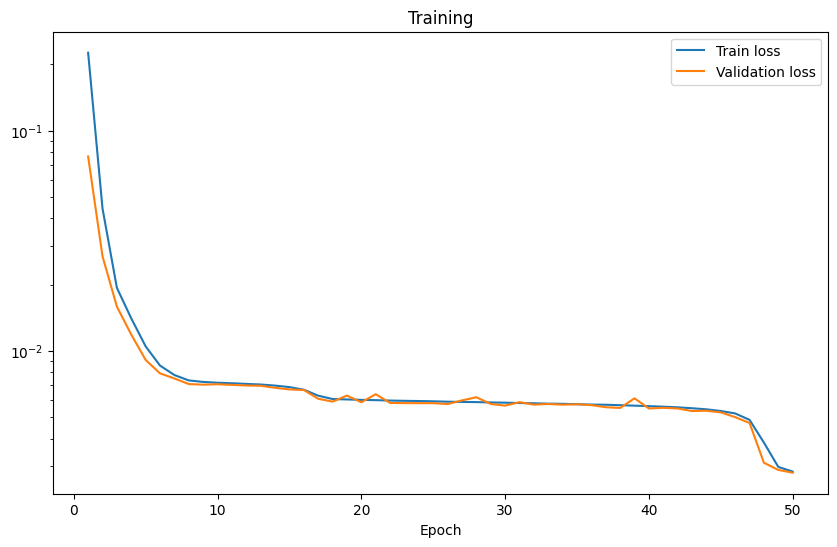

In [ ]:
plt.figure(figsize=(10,6))
plt.title("Training")
plt.plot(np.arange(1, num_epochs+1), avg_t_loss_s, label="Train loss")
plt.plot(np.arange(1, num_epochs+1), avg_v_loss_s, label="Validation loss")
plt.yscale('log')
plt.xlabel("Epoch")
plt.savefig("training.png")
plt.legend()
plt.close

if False:
    torch.save({
        'model_state_dict': model.state_dict(),
        'y_mean': y_mean,
        'y_std':  y_std,
        }, 'bandpass_NN_v3.pth')

In [ ]:
#Evaluation on the Test Set

model = ScalarNN()    # instantiate architecture first
model_setup_dict = torch.load('bandpass_NN_v3.pth', map_location=device)
model.load_state_dict(model_setup_dict['model_state_dict'])
y_std, y_mean = model_setup_dict['y_std'], model_setup_dict['y_mean'] 
model #.to(device)
model.eval()


NeuralNet(
  (in_l): Linear(in_features=3, out_features=8, bias=True)
  (hl_1): Linear(in_features=8, out_features=8, bias=True)
  (hl_2): Linear(in_features=8, out_features=8, bias=True)
  (hl_3): Linear(in_features=8, out_features=8, bias=True)
  (out_l): Linear(in_features=8, out_features=1, bias=True)
)

In [26]:
with torch.no_grad():
    # Single sample
    errs = []
    total_val_loss = 0
    for X_batch, y_batch in test_loader:
        X_batch = X_batch #.to(device)  # move inputs to GPU
        y_batch = y_batch #.to(device)  # move targets to GPU
        X_b0 = X_batch[0]
        pred_norm = model(X_b0)
        pred = pred_norm * y_std + y_mean           # denormalize output
        err = abs((pred - y_batch[0].item()))/y_batch[0].item()
        print(f"Params: [{X_b0[0]}, {X_b0[1]}, {X_b0[2]}], Preds = {pred.item():.4f}, True = {y_batch[0].item():.4f}, err = {err}")
        errs.append(err)
        loss  = criterion(pred, y_batch)
        total_val_loss += loss.item() * len(y_batch)

Params: [-10.0, 1.600000023841858, 10.0], Preds = 866.2864, True = 863.6838, err = 0.003013405903571548
Params: [-10.0, 1.6571428775787354, 13.809523582458496], Preds = 866.3024, True = 861.8459, err = 0.00517085291989339
Params: [-10.0, 1.7428570985794067, 13.428571701049805], Preds = 866.2978, True = 861.5145, err = 0.005552192447907686
Params: [-10.0, 1.8285714387893677, 13.047618865966797], Preds = 866.2932, True = 861.1963, err = 0.005918426184812059
Params: [-10.0, 1.914285659790039, 12.666666984558105], Preds = 866.2886, True = 860.8893, err = 0.006271732070967406
Params: [-10.0, 2.0, 12.285714149475098], Preds = 866.2840, True = 860.5916, err = 0.0066145099496082195
Params: [-10.0, 2.085714340209961, 11.904762268066406], Preds = 866.2794, True = 860.3010, err = 0.006949166524268774
Params: [-10.0, 2.171428680419922, 11.523809432983398], Preds = 866.2748, True = 860.0154, err = 0.007278187336320309
Params: [-9.047618865966797, 1.6285713911056519, 11.142857551574707], Preds = 866

/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/nn/modules/loss.py:1119: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)
/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/nn/modules/loss.py:1119: UserWarning: Using a target size (torch.Size([24])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)


/tmp/ipykernel_19048/3159281034.py:54: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)


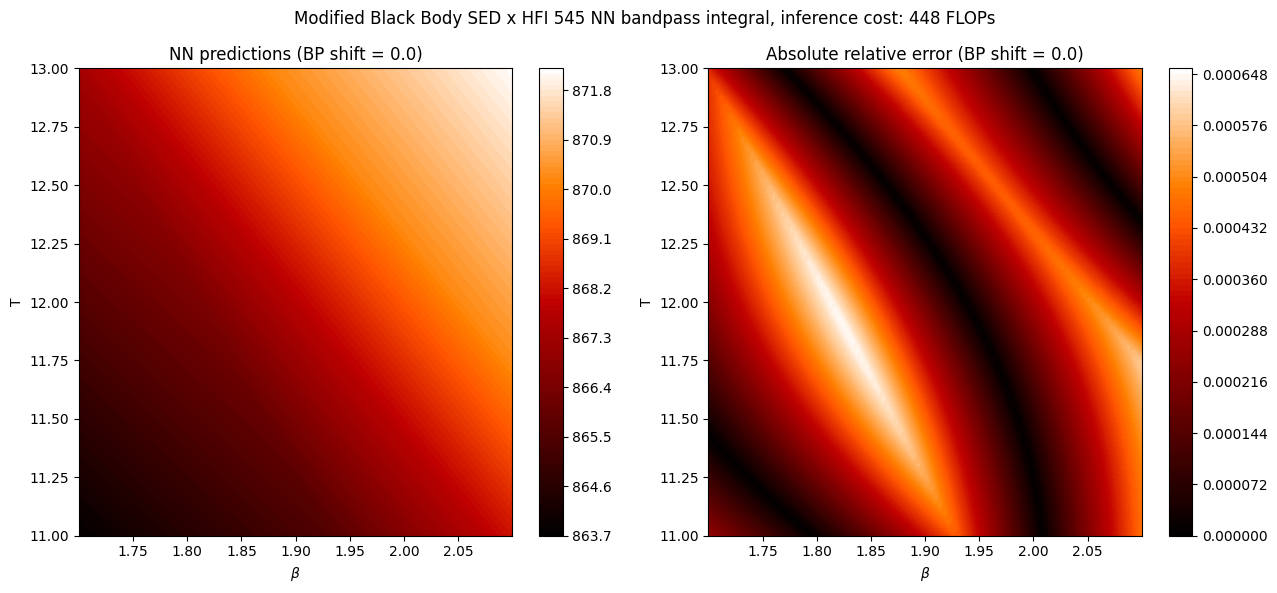

In [46]:
samp_intervals = {
    "BP_shift":(-8., 8.),
    "Beta":(1.7, 2.1),
    "T":(11., 13.)
}
N_vals = 100
bp_path = "bp_planck_545-2_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

#Torch grid
beta_s = torch.linspace(samp_intervals["Beta"][0], samp_intervals["Beta"][1], N_vals)
t_s = torch.linspace(samp_intervals["T"][0], samp_intervals["T"][1], N_vals)
bp_s_fixed = 0.0 

grid_b, grid_t = torch.meshgrid(beta_s, t_s, indexing='ij')

X_grid = torch.stack([
    torch.full((N_vals*N_vals,), bp_s_fixed),
    grid_b.flatten(),
    grid_t.flatten()
], dim=1)

model.eval()

# Run in batches to avoid memory issues on large grids
all_true = []
with torch.no_grad():
    preds_grid = model(X_grid) * y_std + y_mean
    for b in range(len(X_grid)):
        all_true.append(integral(X_grid[b][0].item(), X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))
trues_grid=np.array(all_true).reshape((N_vals,N_vals))

#Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Modified Black Body SED x HFI 545 NN bandpass integral, inference cost: {model.flops} FLOPs")
cf = ax[0].contourf(
    grid_b.numpy(),         # x axis  shape: (100, 100)
    grid_t.numpy(),         # y axis  shape: (100, 100)
    preds_grid,             # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[0])
ax[0].set_xlabel(r'$\beta$')
ax[0].set_ylabel('T')
ax[0].set_title(f'NN predictions (BP shift = {bp_s_fixed})')

cf = ax[1].contourf(
    grid_b.numpy(),       # x axis  shape: (100, 100)
    grid_t.numpy(),       # y axis  shape: (100, 100)
    np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[1])
ax[1].set_xlabel(r'$\beta$')
ax[1].set_ylabel('T')
ax[1].set_title(f'Absolute relative error (BP shift = {bp_s_fixed})')
plt.tight_layout()
plt.show()

/tmp/ipykernel_19048/2685985339.py:56: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)


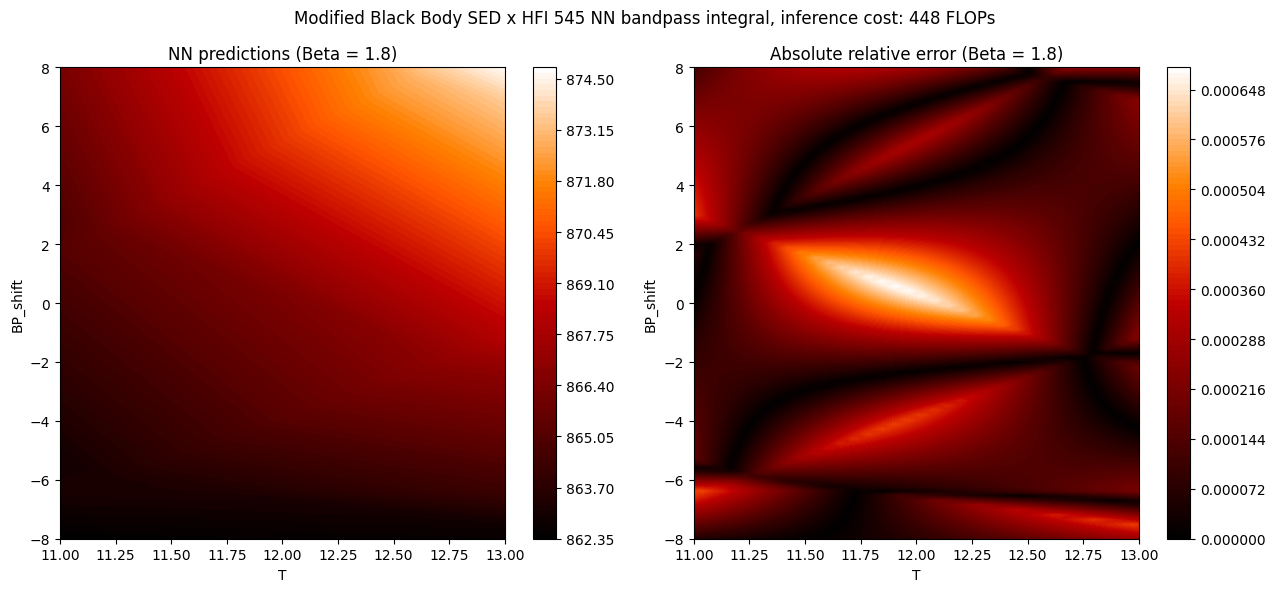

In [47]:
samp_intervals = {
    "BP_shift":(-8., 8.),
    "Beta":(1.7, 2.1),
    "T":(11., 13.)
}
N_vals = 100
bp_path = "bp_planck_545-2_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

#Torch grid
beta_fixed = 1.8
t_s = torch.linspace(samp_intervals["T"][0], samp_intervals["T"][1], N_vals)
bp_s = torch.linspace(samp_intervals["BP_shift"][0], samp_intervals["BP_shift"][1], N_vals)

grid_t, grid_bps = torch.meshgrid(t_s, bp_s, indexing='ij')

X_grid = torch.stack([
    grid_bps.flatten(),
    torch.full((N_vals*N_vals,), beta_fixed),
    grid_t.flatten()
], dim=1)

model.eval()

# Run in batches to avoid memory issues on large grids
all_true = []
with torch.no_grad():
    preds_grid = model(X_grid) * y_std + y_mean
    for b in range(len(X_grid)):
        all_true.append(integral(X_grid[b][0].item(), X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))

trues_grid=np.array(all_true).reshape((N_vals,N_vals))


#Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Modified Black Body SED x HFI 545 NN bandpass integral, inference cost: {model.flops} FLOPs")
cf = ax[0].contourf(
    grid_t.numpy(),         # x axis  shape: (100, 100)
    grid_bps.numpy(),         # y axis  shape: (100, 100)
    preds_grid,             # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[0])
ax[0].set_xlabel('T')
ax[0].set_ylabel('BP_shift')
ax[0].set_title(f'NN predictions (Beta = {beta_fixed})')

cf = ax[1].contourf(
    grid_t.numpy(),       # x axis  shape: (100, 100)
    grid_bps.numpy(),       # y axis  shape: (100, 100)
    np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[1])
ax[1].set_xlabel('T')
ax[1].set_ylabel('BP_shift')
ax[1].set_title(f'Absolute relative error (Beta = {beta_fixed})')
plt.tight_layout()
plt.show()

/tmp/ipykernel_19048/2198155001.py:54: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)


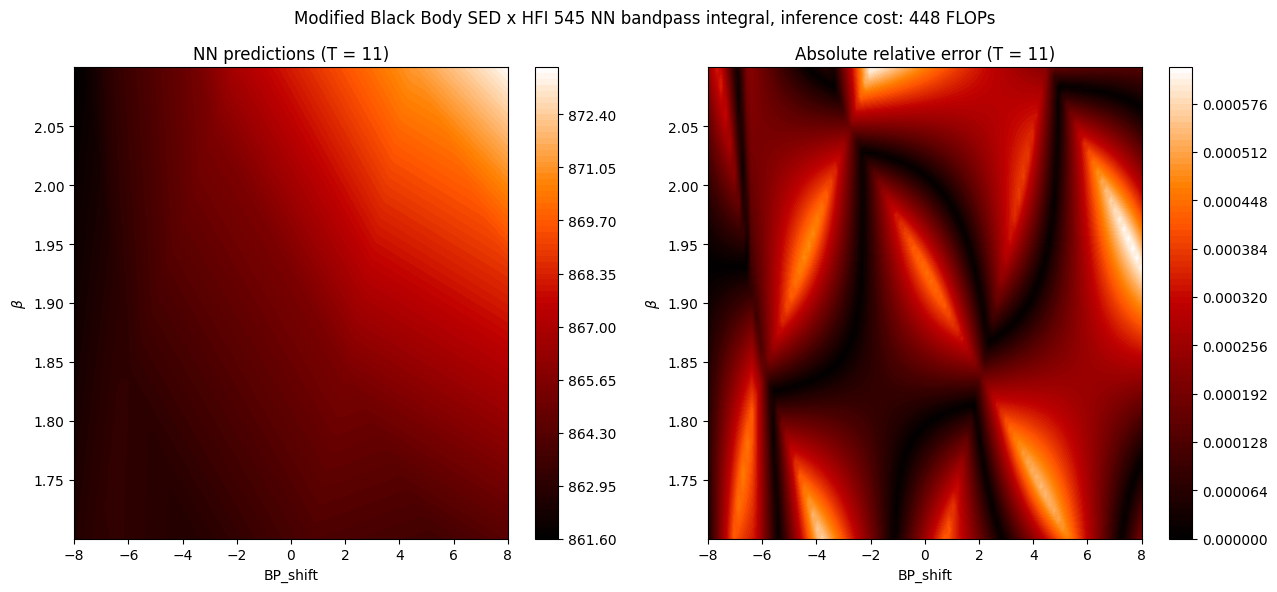

In [48]:
samp_intervals = {
    "BP_shift":(-8., 8.),
    "Beta":(1.7, 2.1),
    "T":(11., 13.)
}
N_vals = 100
bp_path = "bp_planck_545-2_v2015.dat"
bp_dat = np.loadtxt(bp_path).transpose()
bp_dat = bp_dat[:,300:2500]

#Torch grid
T_fixed = 11
beta_s = torch.linspace(samp_intervals["Beta"][0], samp_intervals["Beta"][1], N_vals)
bp_s = torch.linspace(samp_intervals["BP_shift"][0], samp_intervals["BP_shift"][1], N_vals)

grid_bps, grid_beta = torch.meshgrid(bp_s, beta_s, indexing='ij')

X_grid = torch.stack([
    grid_bps.flatten(),
    grid_beta.flatten(),
    torch.full((N_vals*N_vals,), T_fixed)
], dim=1)

model.eval()

# Run in batches to avoid memory issues on large grids
all_true = []
with torch.no_grad():
    preds_grid = model(X_grid) * y_std + y_mean
    for b in range(len(X_grid)):
        all_true.append(integral(X_grid[b][0].item(), X_grid[b][1].item(), X_grid[b][2].item(), bp_dat))

preds_grid = preds_grid.reshape((N_vals,N_vals))
trues_grid=np.array(all_true).reshape((N_vals,N_vals))

#Plot
fig, ax = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Modified Black Body SED x HFI 545 NN bandpass integral, inference cost: {model.flops} FLOPs")
cf = ax[0].contourf(
    grid_bps.numpy(),         # x axis  shape: (100, 100)
    grid_beta.numpy(),         # y axis  shape: (100, 100)
    preds_grid,             # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[0])
ax[0].set_xlabel('BP_shift')
ax[0].set_ylabel(r'$\beta$')
ax[0].set_title(f'NN predictions (T = {T_fixed})')

cf = ax[1].contourf(
    grid_bps.numpy(),       # x axis  shape: (100, 100)
    grid_beta.numpy(),       # y axis  shape: (100, 100)
    np.abs(preds_grid - trues_grid)/trues_grid,    # values  shape: (100, 100)
    levels=100,             # number of color bands
    cmap='gist_heat'         # colormap
)
plt.colorbar(cf, ax=ax[1])
ax[1].set_xlabel('BP_shift')
ax[1].set_ylabel(r'$\beta$')
ax[1].set_title(f'Absolute relative error (T = {T_fixed})')
plt.tight_layout()
plt.show()